# Prototipo del modelo de estrategia con XGBoost

Primera versión del modelo, entrenada sobre una sola carrera (Silverstone 2024).
Sirve para responder si la degradación de neumático es predecible a partir de
tres variables sencillas —vida de la goma, número de vuelta y compuesto— antes de
invertir tiempo en montar el pipeline completo.

**Lo que este notebook predice es el tiempo de vuelta absoluto.** Funciona bien
acá y esa es justamente la trampa: el modelo aprende cuánto se tarda en dar una
vuelta *en Silverstone*. Llevado a Monza o a Singapur, donde el ritmo base son
20 segundos de diferencia, no sirve para nada.

La versión de producción (`src/entrenamiento_modelo.py`) corrige eso: predice el
delta contra la mejor vuelta del propio piloto en esa carrera, que mide
degradación pura y sí se transfiere entre circuitos. También agrega la corrección
por combustible y valida contra un circuito entero que el modelo nunca vio, en
lugar de un split aleatorio.


## 1. Preparación de la matriz de features

Tres variables predictoras, cada una con una justificación distinta:

- **`TyreLife`** — vueltas que lleva la goma montada. Es la variable de interés:
  la degradación en sí.
- **`LapNumber`** — vuelta de la carrera. Entra como aproximación de la carga de
  combustible, que no viene en los datos: cuanto más avanzada la carrera, menos
  nafta y más liviano el auto. En la versión de producción esto se reemplaza por
  una corrección explícita de 0,055 s por vuelta restante, que es más honesta
  que dejar que el modelo lo infiera.
- **`Compound`** — el compuesto. Es categórica, así que se codifica con one-hot:
  XGBoost solo acepta entradas numéricas y asignarle 1, 2, 3 le impondría un
  orden que no existe.


In [1]:
"""
Ingeniería de features para el modelo de estrategia.

Lee el silver, descarta las vueltas que no representan ritmo de carrera y arma
la matriz de entrada codificando el compuesto.
"""

import pandas as pd
import numpy as np

# Ruta al Parquet ya procesado por PySpark.
SILVER_DIR = r"C:\Users\gabst\data\silver\2024_silverstone_R_silver.parquet"

print("INFO: Loading Silver layer data...")
df = pd.read_parquet(SILVER_DIR)

# 1. Filtro base: saca safety car, VSC y vueltas de entrada y salida de boxes.
# El ritmo seco de Silverstone vive entre los 85 y los 105 segundos; cualquier
# cosa fuera de esa ventana es otra situación de carrera, no ritmo.
df_model = df[(df['LapTime'] > 85) & (df['LapTime'] < 105)].copy()

# 2. Selección de variables.
# TyreLife es la degradación propiamente dicha; LapNumber entra como proxy de la
# carga de combustible, que no viene en los datos; Compound porque cada goma
# tiene su propia curva de caída.
features = ['TyreLife', 'LapNumber', 'Compound']
target = 'LapTime'

df_model = df_model[features + [target]].dropna()

# 3. Codificación de la categórica.
# One-hot y no un entero por compuesto: numerarlos le metería un orden inventado
# (que HARD "vale más" que SOFT) del que el modelo terminaría sacando conclusiones.
df_encoded = pd.get_dummies(df_model, columns=['Compound'], drop_first=False)

print(f"INFO: Feature Matrix shape after encoding: {df_encoded.shape}")
display(df_encoded.head())


INFO: Loading Silver layer data...
INFO: Feature Matrix shape after encoding: (858, 7)


,TyreLife,LapNumber,LapTime,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT
0,1,1,96.034,False,False,True,False
1,2,2,91.420,False,False,True,False
2,3,3,91.716,False,False,True,False
3,4,4,91.988,False,False,True,False
4,5,5,91.677,False,False,True,False


## 2. Entrenamiento

Split aleatorio 80/20. Es la decisión más débil del prototipo: como las vueltas
de una misma carrera se parecen mucho entre sí, hay filas casi idénticas a ambos
lados del corte y el error de validación sale optimista.

En producción se reserva un circuito completo como holdout, que es la única forma
de saber si el modelo generaliza a una pista que no vio.


In [2]:
"""
Entrenamiento del regresor XGBoost.

Separa entrenamiento y validación, define los hiperparámetros y mide el error
sobre las vueltas que el modelo no vio.
"""

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

X = df_encoded.drop(columns=['LapTime'])
y = df_encoded['LapTime']

# Split aleatorio 80/20. Con una sola carrera el número que sale es optimista:
# vueltas consecutivas se parecen tanto que quedan casi duplicadas a los dos
# lados del corte. El pipeline de producción valida contra un circuito entero.
# random_state fijo para que el resultado sea reproducible entre corridas.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("INFO: Initializing XGBoost Regressor...")
# Configuración conservadora para un dataset chico: profundidad acotada y
# submuestreo de filas y columnas para que no memorice el ruido de las vueltas.
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

print("INFO: Training model...")
xgb_model.fit(X_train, y_train)

# Evaluación sobre datos no vistos.
# RMSE castiga más los errores grandes; MAE se lee directo en segundos.
y_pred = xgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"SUCCESS: Model trained successfully.")
print(f"Validation RMSE: {rmse:.3f} seconds (Root Mean Squared Error)")
print(f"Validation MAE:  {mae:.3f} seconds (Mean Absolute Error)")


INFO: Initializing XGBoost Regressor...
INFO: Training model...
SUCCESS: Model trained successfully.
Validation RMSE: 1.119 seconds (Root Mean Squared Error)
Validation MAE:  0.815 seconds (Mean Absolute Error)


## 3. Evaluación

Dos lecturas complementarias:

- **Importancia de features.** Confirma que el modelo está usando la degradación
  y no apoyándose solo en el número de vuelta.
- **Real contra predicho.** Si el modelo fuera perfecto, todos los puntos caerían
  sobre la diagonal. Lo que interesa no es que estén cerca, sino que no haya
  estructura en la desviación: una curva o un abanico indican un efecto físico
  que las features no capturan.


C:\Users\gabst\AppData\Local\Temp\ipykernel_20748\1573365409.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=feature_names, ax=axes[0], palette="viridis")


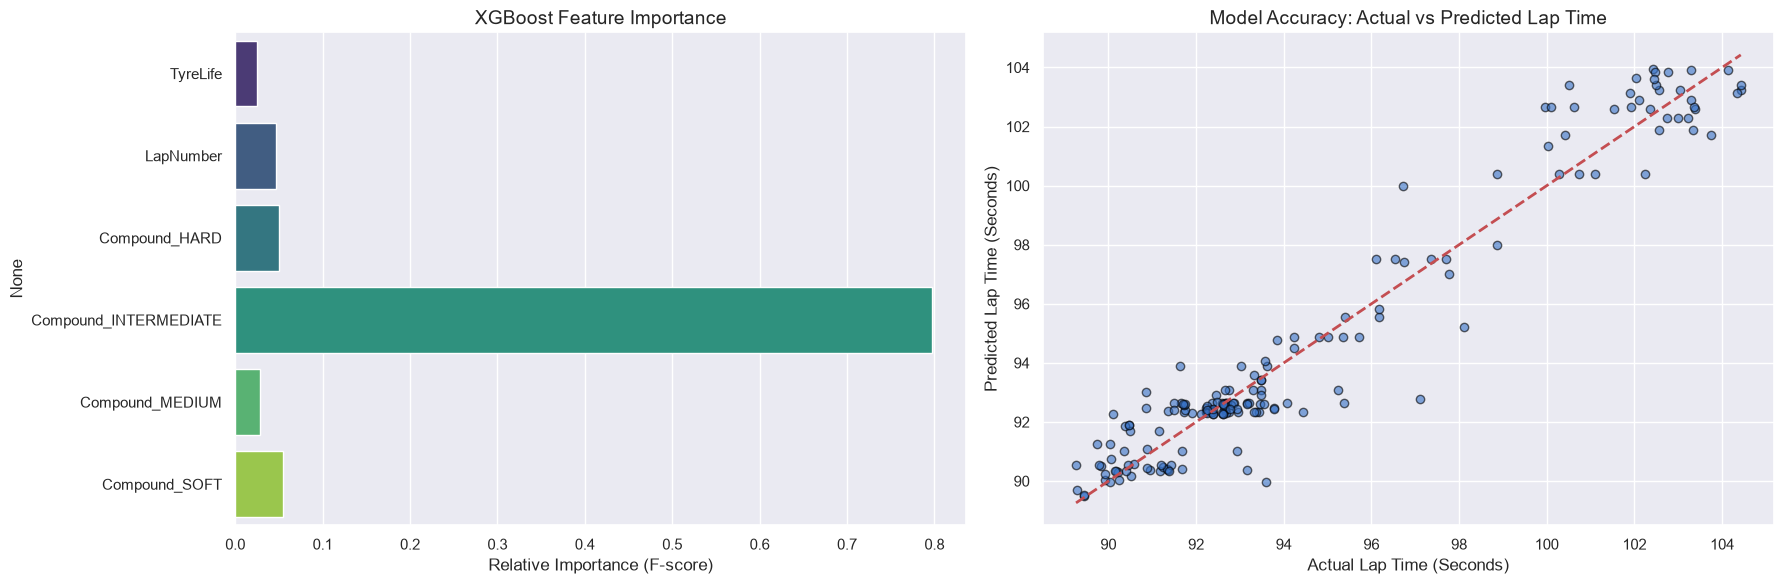

In [3]:
"""
Evaluación visual del modelo.

Importancia de cada variable y comparación entre el tiempo real y el predicho.
"""

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: importancia de las features.
# Muestra de qué se agarra el modelo. Si TyreLife no pesa, no está aprendiendo
# degradación sino alguna otra cosa.
importance = xgb_model.feature_importances_
feature_names = X.columns
sns.barplot(x=importance, y=feature_names, ax=axes[0], palette="viridis")
axes[0].set_title("XGBoost Feature Importance", fontsize=14)
axes[0].set_xlabel("Relative Importance (F-score)")

# Panel 2: real contra predicho.
# La diagonal es el modelo perfecto. Importa más la forma de la dispersión que
# su ancho: una curvatura delata un efecto físico que las features no capturan.
axes[1].scatter(y_test, y_pred, alpha=0.6, color="#3671C6", edgecolor="black")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title("Model Accuracy: Actual vs Predicted Lap Time", fontsize=14)
axes[1].set_xlabel("Actual Lap Time (Seconds)")
axes[1].set_ylabel("Predicted Lap Time (Seconds)")

plt.tight_layout()
plt.show()


## 4. Métricas relativas y control con lluvia

El MAE en segundos no dice si un error es grande sin saber cuánto dura una
vuelta. R² y MAPE dan esa referencia relativa.

El desglose final atiende un problema que el filtro de tiempos no resuelve: la
ventana de 85 a 105 segundos deja pasar vueltas con neumático intermedio que
casualmente caen en ese rango. Esas vueltas son lentas por la pista mojada, no
por la goma gastada, y el modelo no tiene forma de distinguirlo. Separar el error
en seco muestra cuánto de la imprecisión viene de ahí.

Esta observación es la que lleva a que el pipeline de producción filtre por
compuesto directamente, en vez de confiar en la ventana de tiempos.


In [4]:
"""
Métricas relativas y control sobre vueltas de lluvia.

R² y MAPE ponen el error en escala; el desglose por compuesto aísla cuánto de
la imprecisión viene de vueltas con pista mojada.
"""
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# El MAE en segundos no dice si el error es grande sin saber cuánto dura la
# vuelta. R² mide qué proporción de la variación explica el modelo y MAPE
# expresa el error como porcentaje del tiempo real.
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("--- Evaluación Avanzada del Modelo ---")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MAPE (Error Porcentual Absoluto Medio): {mape:.2f}%")

# La ventana de 85 a 105 segundos filtra por tiempo, no por compuesto: alguna
# vuelta con intermedios cae dentro del rango y entra al entrenamiento. Es lenta
# por la pista mojada, no por la goma gastada, y el modelo no puede distinguirlo.
df_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# El join recupera el compuesto original por índice, que se perdió al armar X.
df_results = df_results.join(df_encoded[['Compound_INTERMEDIATE']])
df_dry = df_results[df_results['Compound_INTERMEDIATE'] == False]

# Comparar este MAE con el general dimensiona cuánto ensucia la lluvia. La
# diferencia es la que justifica filtrar por compuesto en el pipeline final.
if not df_dry.empty:
    mae_dry = mean_absolute_error(df_dry['Actual'], df_dry['Predicted'])
    print(f"MAE solo en Pista Seca: {mae_dry:.3f} segundos")


--- Evaluación Avanzada del Modelo ---
R² (Coeficiente de Determinación): 0.9358
MAPE (Error Porcentual Absoluto Medio): 0.85%
MAE solo en Pista Seca: 0.773 segundos
